<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/experiment2/Experiment2_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Die zwei erweiterten CSVs laden:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base = "/content/drive/MyDrive/ba_results/"
df_cotracker = pd.read_csv(base + "cotracker3_all_videos_v2.csv")
df_tapnext = pd.read_csv(base + "tapnext_all_videos_v2.csv")

df_exp2 = pd.concat([df_cotracker, df_tapnext], ignore_index=True)
df_exp2.to_csv(base + "experiment2_combined.csv", index=False)

blur_order = ["none", "medium", "strong"]
print(df_exp2.groupby(["model", "blur"])[["occlusion_accuracy", "outlier_magnitude", "trajectory_length_ratio"]].mean())

Mounted at /content/drive
                   occlusion_accuracy  outlier_magnitude  \
model      blur                                            
CoTracker3 medium           80.375335           8.248906   
           none             88.130537          10.800813   
           strong           66.902586           6.904527   
TapNext    medium           77.255704          51.851578   
           none             91.340181          52.450184   
           strong           62.053555          55.709393   

                   trajectory_length_ratio  
model      blur                             
CoTracker3 medium                 0.857388  
           none                   0.901007  
           strong                 0.841268  
TapNext    medium                 0.949729  
           none                   0.993718  
           strong                 1.101864  


Zelle 2 – Vergleichsplots für alle drei Experiment-2-Metriken:

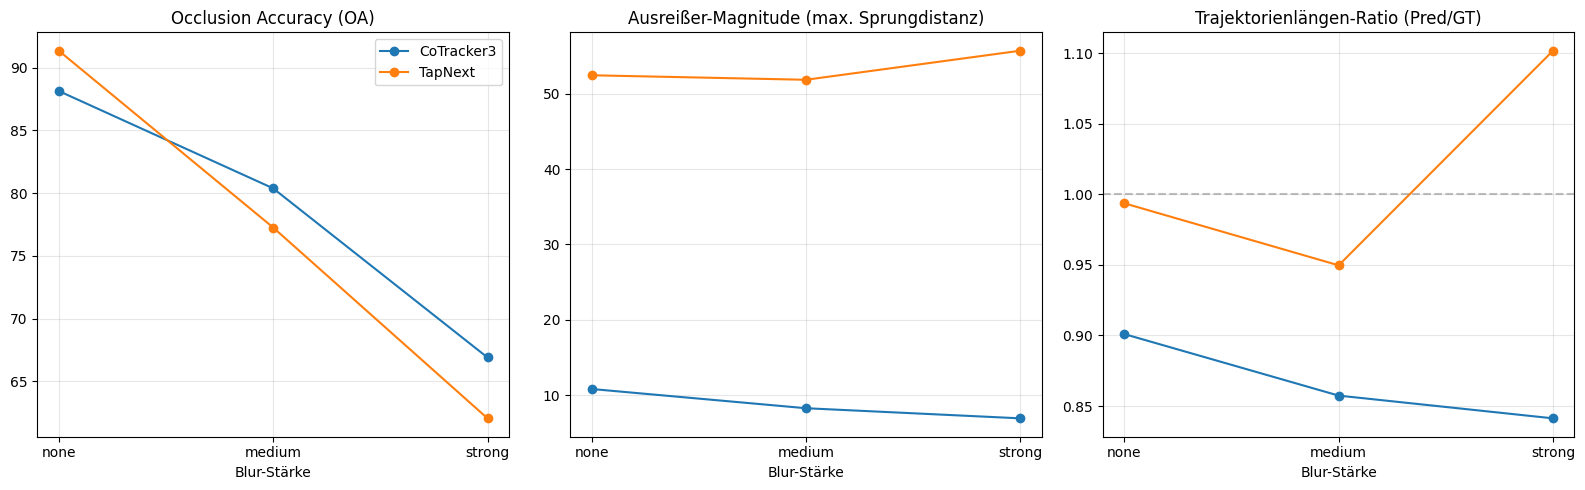

                   occlusion_accuracy  outlier_magnitude  \
model      blur                                            
CoTracker3 medium               80.38               8.25   
           none                 88.13              10.80   
           strong               66.90               6.90   
TapNext    medium               77.26              51.85   
           none                 91.34              52.45   
           strong               62.05              55.71   

                   trajectory_length_ratio  
model      blur                             
CoTracker3 medium                     0.86  
           none                       0.90  
           strong                     0.84  
TapNext    medium                     0.95  
           none                       0.99  
           strong                     1.10  


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["occlusion_accuracy", "outlier_magnitude", "trajectory_length_ratio"]
titles = ["Occlusion Accuracy (OA)", "Ausreißer-Magnitude (max. Sprungdistanz)", "Trajektorienlängen-Ratio (Pred/GT)"]

for ax, metric, title in zip(axes, metrics, titles):
    summary = df_exp2.groupby(["model", "blur"])[metric].mean().reset_index()
    for model_name in ["CoTracker3", "TapNext"]:
        sub = summary[summary["model"] == model_name].set_index("blur").reindex(blur_order)
        ax.plot(blur_order, sub[metric], marker="o", label=model_name)
    ax.set_title(title)
    ax.set_xlabel("Blur-Stärke")
    ax.grid(alpha=0.3)
    if metric == "trajectory_length_ratio":
        ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="GT-Niveau")

axes[0].legend()
plt.tight_layout()
plt.savefig(base + "experiment2_comparison.png", dpi=150)
plt.show()

final_table_exp2 = df_exp2.groupby(["model", "blur"])[metrics].mean().round(2)
print(final_table_exp2)
final_table_exp2.to_csv(base + "experiment2_summary_table.csv")

Qualitative Jitter Comparison:

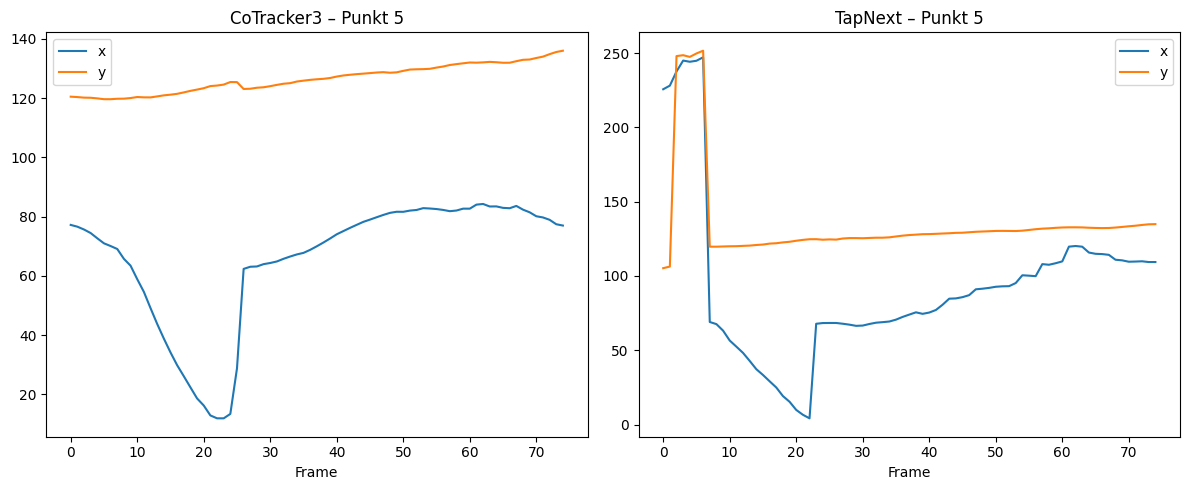

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

traj_ct3 = np.load(base + "cotracker3_traj_video1_strong.npy")
traj_tapnext = np.load(base + "tapnext_traj_video1_strong.npy")

point_idx = 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(traj_ct3[point_idx, :, 0], label="x")
axes[0].plot(traj_ct3[point_idx, :, 1], label="y")
axes[0].set_title(f"CoTracker3 – Punkt {point_idx}")
axes[0].set_xlabel("Frame")
axes[0].legend()

axes[1].plot(traj_tapnext[point_idx, :, 0], label="x")
axes[1].plot(traj_tapnext[point_idx, :, 1], label="y")
axes[1].set_title(f"TapNext – Punkt {point_idx}")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(base + "qualitative_jitter_comparison.png", dpi=150)
plt.show()

Für jeden der 20 Punkte maximale Sprungdistanz testen:

In [ ]:
diffs_ct3 = np.linalg.norm(traj_ct3[:, 1:] - traj_ct3[:, :-1], axis=-1)  # (20, T-1)
diffs_tapnext = np.linalg.norm(traj_tapnext[:, 1:] - traj_tapnext[:, :-1], axis=-1)

max_jump_ct3 = diffs_ct3.max(axis=1)
max_jump_tapnext = diffs_tapnext.max(axis=1)

contrast = max_jump_tapnext - max_jump_ct3
best_point = np.argmax(contrast)

print("Bester Kontrast-Punkt:", best_point)
print("CoTracker3 max. Sprung:", max_jump_ct3[best_point])
print("TapNext max. Sprung:", max_jump_tapnext[best_point])

Bester Kontrast-Punkt: 8
CoTracker3 max. Sprung: 11.815926
TapNext max. Sprung: 224.43611


Point Index = 8:

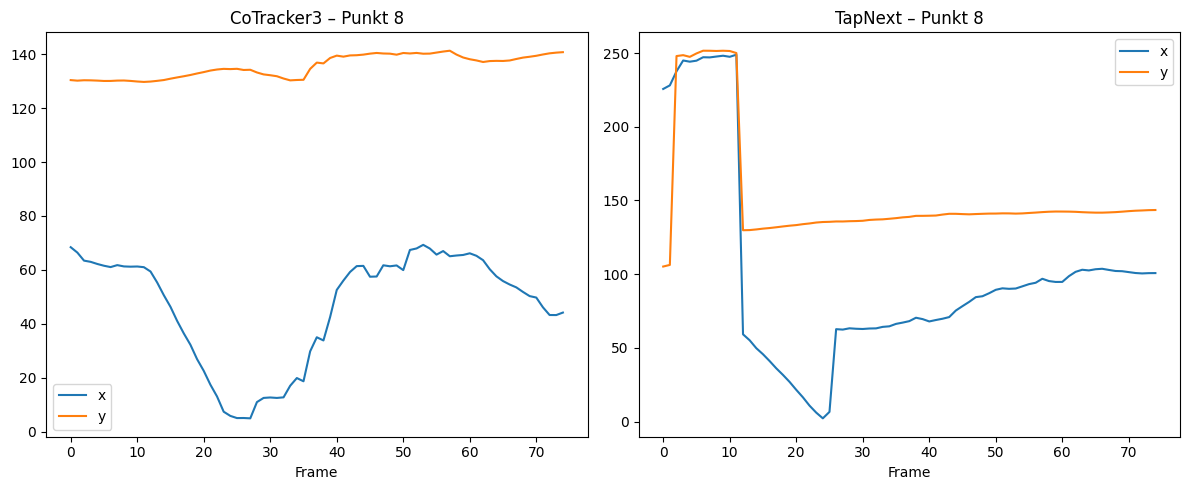

In [ ]:
point_idx = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(traj_ct3[point_idx, :, 0], label="x")
axes[0].plot(traj_ct3[point_idx, :, 1], label="y")
axes[0].set_title(f"CoTracker3 – Punkt {point_idx}")
axes[0].set_xlabel("Frame")
axes[0].legend()

axes[1].plot(traj_tapnext[point_idx, :, 0], label="x")
axes[1].plot(traj_tapnext[point_idx, :, 1], label="y")
axes[1].set_title(f"TapNext – Punkt {point_idx}")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(base + "qualitative_jitter_comparison.png", dpi=150)
plt.show()